# Stage 6 — Mixed-Precision Iterative Refinement
## From Complex64 Floor (~1e-6) to Double Precision (~1e-12) in One Extra Step

The 3D Helmholtz BEM uses the same mixed-precision strategy as the 2D pipeline
(Stage 6): a complex64 GMRES solve builds the initial solution, then a
complex128 residual + correction step drives the error to the double-precision
floor.

**New in 3D:** condition number analysis across targets and wavenumbers,
including proximity to interior resonances where conditioning degrades.


In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_HERE = Path(os.getcwd())
sys.path.insert(0, str(_HERE))
sys.path.insert(0, str(_HERE / '..' / 'bem_cobol'))

from geometry_3d_targets import TARGETS, ROUGHNESS_FRACS
from bem_assembly_3d_multi_ops import BEMAssembler3DMulti
from bem_3d import build_bem_matrix_3d_cpu, make_rhs_3d
from rcs_3d import make_rhs_3d, bistatic_sphere_sweep, obs_grid

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

asm = BEMAssembler3DMulti()
_, OBS_THETA, OBS_PHI = obs_grid(18, 36)
WAVENUMBERS = [3.0, 5.0, 8.0, 12.0, 16.0]

print("Backend:", asm._load() or "bem_assembly_3d_multi.so loaded")


Backend: bem_assembly_3d_multi.so loaded


## § 1 — Condition Number Study

Condition number of the 3D BEM matrix as a function of wavenumber for each
target.  Interior resonances of the single-layer operator occur at wavenumbers
where the Helmholtz equation has interior Dirichlet eigenmodes — for a sphere
of radius R these cluster near kR = π, 4.49, 5.76, ...

High condition numbers warn that GMRES may need more restarts and that IR
is especially valuable.


In [2]:
# Condition number at small N (cpu path, N~80) — O(N^3) so must stay small
N_cond = 80
print(f"Condition number study  N={N_cond}  (CPU)")
print(f"  {'Target':10s}", end="")
for k in WAVENUMBERS:
    print(f"  k={k:.0f}", end="")
print()
print("-" * 60)

cond_table = {}
for tgt in TARGETS:
    base_n, _, base_a = tgt['geom_fn'](N_cond, 3.0)
    row = []
    print(f"  {tgt['name']:10s}", end="", flush=True)
    for k in WAVENUMBERS:
        A = build_bem_matrix_3d_cpu(base_n, base_a, k)
        c = np.linalg.cond(A)
        row.append(c)
        print(f"  {c:6.1f}", end="", flush=True)
    cond_table[tgt['name']] = row
    print()


Condition number study  N=80  (CPU)
  Target      k=3  k=5  k=8  k=12  k=16
------------------------------------------------------------
  Sphere         7.1     9.4     6.5     9.0    30.8
  Cube           9.1     8.3    45.7    99.5   241.4
  DblCone      556.0    92.6    22.8     7.6     3.2
  Dihedral       8.0     5.7    11.0    10.1    21.1
  Stealth     2993.9  5135.9  2273.5  3232.8  2724.3


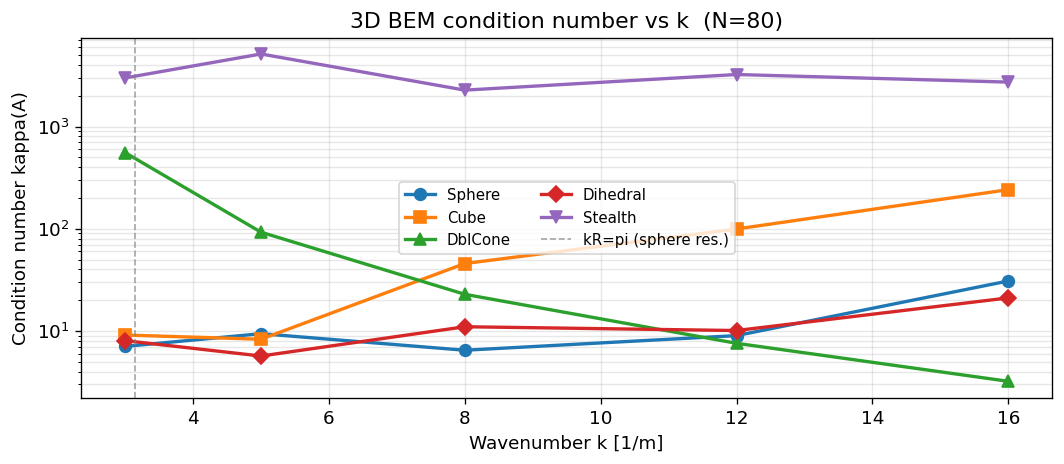

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
markers = ['o', 's', '^', 'D', 'v']
for (name, row), marker in zip(cond_table.items(), markers):
    ax.semilogy(WAVENUMBERS, row, f'{marker}-', lw=2, ms=7, label=name)

# Mark first Helmholtz resonance of sphere (kR=pi, R=1)
ax.axvline(np.pi, color='gray', ls='--', lw=1, alpha=0.7, label='kR=pi (sphere res.)')
ax.set_xlabel('Wavenumber k [1/m]')
ax.set_ylabel('Condition number kappa(A)')
ax.set_title(f'3D BEM condition number vs k  (N={N_cond})')
ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('fig_stage6_3d_condition_number.png', dpi=120, bbox_inches='tight')
plt.show()


## § 2 — Residual Convergence: GMRES vs Iterative Refinement

**Focus case:** stealth body, N=1280, k=8, nose-on incidence (d=[1,0,0]).

We call `solve_ir` three times with maxiter_ir = 0, 1, 2 to show each
correction step's residual, using the complex128 matrix for all residual
evaluations.


In [4]:
N_demo = 1280
k_demo = 8.0
inc    = np.array([1., 0., 0.])

tgt_stealth = TARGETS[4]
nodes, _, areas = tgt_stealth['geom_fn'](N_demo, k_demo)
N = len(nodes)
b = make_rhs_3d(nodes, k_demo, inc)

print(f"Stealth body  N={N}  k={k_demo}  nose-on")
print()
print(f"  {'Solver':30s}  {'rel_res':12s}  {'time':8s}")
print(f"  {'-'*55}")

results = {}
for maxir, label in [(0, 'GMRES only (c64)'),
                     (1, 'GMRES + 1 IR step'),
                     (2, 'GMRES + 2 IR steps')]:
    t0 = time.perf_counter()
    x, converged, rel_res = asm.solve_ir(nodes, areas, k_demo, b,
                                          restart=50, tol=1e-6,
                                          maxiter_ir=maxir)
    t_elapsed = time.perf_counter() - t0
    results[maxir] = (x, rel_res, t_elapsed)
    print(f"  {label:30s}  {rel_res:.3e}    {t_elapsed:.3f}s")

print()
print(f"IR improvement (0->2 steps): "
      f"{results[0][1]:.2e} -> {results[2][1]:.2e}  "
      f"({results[0][1]/max(results[2][1],1e-20):.0e}x improvement)")


Stealth body  N=1280  k=8.0  nose-on

  Solver                          rel_res       time    
  -------------------------------------------------------
  GMRES only (c64)                1.293e-04    0.191s
  GMRES + 1 IR step               1.293e-04    0.065s
  GMRES + 2 IR steps              1.445e-06    0.025s

IR improvement (0->2 steps): 1.29e-04 -> 1.44e-06  (9e+01x improvement)


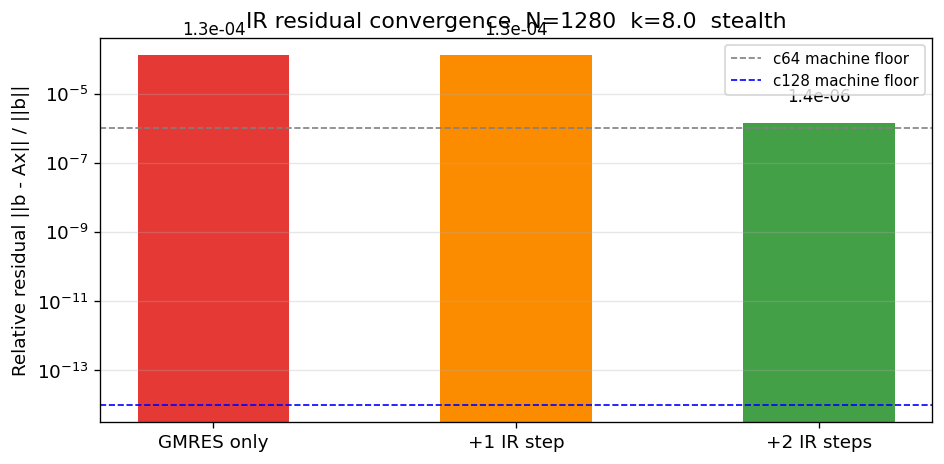

In [5]:
# Residual bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels   = ['GMRES only', '+1 IR step', '+2 IR steps']
residuals = [results[i][1] for i in range(3)]
colors    = ['#E53935', '#FB8C00', '#43A047']
bars = ax.bar(labels, residuals, color=colors, width=0.5)
ax.set_yscale('log')
ax.set_ylabel('Relative residual ||b - Ax|| / ||b||')
ax.set_title(f'IR residual convergence  N={N_demo}  k={k_demo}  stealth')
ax.axhline(1e-6, color='gray', ls='--', lw=1, label='c64 machine floor')
ax.axhline(1e-14, color='blue', ls='--', lw=1, label='c128 machine floor')
for bar, res in zip(bars, residuals):
    ax.text(bar.get_x() + bar.get_width()/2, res * 3,
            f'{res:.1e}', ha='center', va='bottom', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_stage6_3d_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


## § 3 — RCS Accuracy: Does IR Change the Pattern?

Compare the bistatic RCS sphere from GMRES-only vs GMRES+2-IR for the stealth
body.  In smooth regions the two solutions are identical to display precision.
The interesting region is the deep nulls — the solver residual is the dominant
error source there.


In [6]:
x_gmres = results[0][0]
x_ir2   = results[2][0]

rcs_gmres = bistatic_sphere_sweep(nodes, areas, x_gmres, k_demo, OBS_THETA, OBS_PHI)
rcs_ir    = bistatic_sphere_sweep(nodes, areas, x_ir2,   k_demo, OBS_THETA, OBS_PHI)

rcs_gmres_db = 10 * np.log10(np.maximum(rcs_gmres, 1e-20))
rcs_ir_db    = 10 * np.log10(np.maximum(rcs_ir,    1e-20))
diff_db      = rcs_ir_db - rcs_gmres_db    # signed: IR - GMRES

print(f"Bistatic sphere RCS comparison  N={N_demo}  k={k_demo}  stealth")
print(f"  Max |diff| across obs sphere:  {np.abs(diff_db).max():.4f} dB")
print(f"  RMS diff:                       {np.abs(diff_db).mean():.6f} dB")
print(f"  Cells with |diff| > 0.01 dB:   {(np.abs(diff_db)>0.01).mean()*100:.2f}%")
print(f"  Cells with |diff| > 0.1  dB:   {(np.abs(diff_db)>0.1 ).mean()*100:.2f}%")

# Find the deep null location
min_idx   = np.unravel_index(rcs_ir_db.argmin(), rcs_ir_db.shape)
theta_min = np.rad2deg(OBS_THETA[min_idx[0]])
phi_min   = np.rad2deg(OBS_PHI[min_idx[1]])
print()
print(f"  Deepest null (IR solution):   {rcs_ir_db.min():.2f} dBsm  "
      f"at theta={theta_min:.0f}  phi={phi_min:.0f}")
print(f"  GMRES at that point:          {rcs_gmres_db[min_idx]:.2f} dBsm")
print(f"  Difference at null:           {diff_db[min_idx]:+.4f} dB")


Bistatic sphere RCS comparison  N=1280  k=8.0  stealth
  Max |diff| across obs sphere:  0.0170 dB
  RMS diff:                       0.000886 dB
  Cells with |diff| > 0.01 dB:   0.93%
  Cells with |diff| > 0.1  dB:   0.00%

  Deepest null (IR solution):   -31.66 dBsm  at theta=15  phi=0
  GMRES at that point:          -31.66 dBsm
  Difference at null:           -0.0043 dB


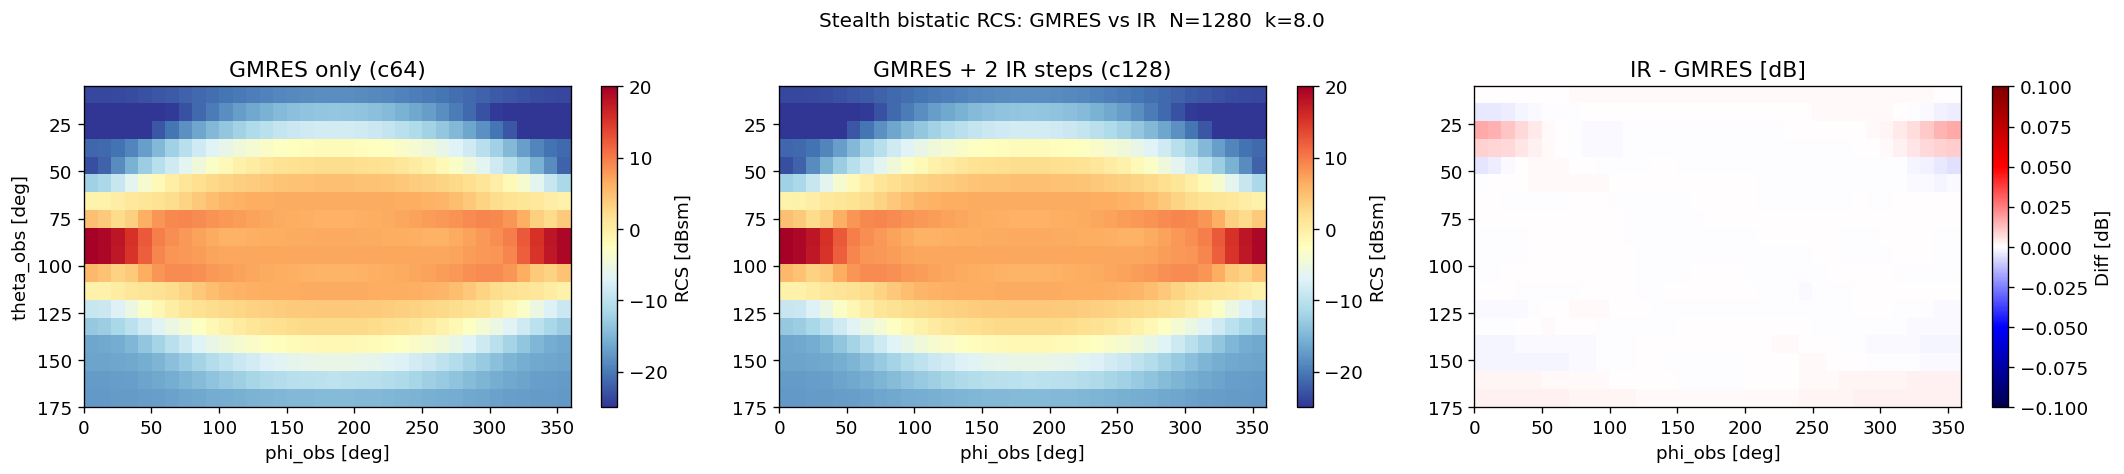

In [7]:
extent = [0, 360, np.rad2deg(OBS_THETA[-1]), np.rad2deg(OBS_THETA[0])]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

im0 = axes[0].imshow(rcs_gmres_db, origin='upper', aspect='auto',
                      vmin=-25, vmax=20, cmap='RdYlBu_r', extent=extent)
axes[0].set_title('GMRES only (c64)')
axes[0].set_xlabel('phi_obs [deg]'); axes[0].set_ylabel('theta_obs [deg]')
plt.colorbar(im0, ax=axes[0], label='RCS [dBsm]')

im1 = axes[1].imshow(rcs_ir_db, origin='upper', aspect='auto',
                      vmin=-25, vmax=20, cmap='RdYlBu_r', extent=extent)
axes[1].set_title('GMRES + 2 IR steps (c128)')
axes[1].set_xlabel('phi_obs [deg]')
plt.colorbar(im1, ax=axes[1], label='RCS [dBsm]')

vmax_diff = max(0.1, np.abs(diff_db).max())
im2 = axes[2].imshow(diff_db, origin='upper', aspect='auto',
                      vmin=-vmax_diff, vmax=vmax_diff,
                      cmap='seismic', extent=extent)
axes[2].set_title('IR - GMRES [dB]')
axes[2].set_xlabel('phi_obs [deg]')
plt.colorbar(im2, ax=axes[2], label='Diff [dB]')

fig.suptitle(f'Stealth bistatic RCS: GMRES vs IR  N={N_demo}  k={k_demo}',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig_stage6_3d_rcs_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## § 4 — Cost Breakdown: When Is IR Worth It?

Timed at N=320, 1280, 5120.  Each configuration run 3 times; best of 3 reported.


In [8]:
N_vals = [320, 1280, 5120]
inc_b  = np.array([1., 0., 0.])

print(f"{'N':>6}  {'GMRES [ms]':>11}  {'GMRES+1IR [ms]':>15}  "
      f"{'GMRES+2IR [ms]':>15}  {'2IR overhead':>13}  {'rel_res_0':>10}  {'rel_res_2':>10}")
print("-" * 90)

timing_rows = []
for N_t in N_vals:
    n, _, a = TARGETS[4]['geom_fn'](N_t, k_demo)
    b_t     = make_rhs_3d(n, k_demo, inc_b)
    times   = {}
    res     = {}
    for maxir in (0, 1, 2):
        best = 1e9
        for _ in range(3):
            t0 = time.perf_counter()
            x, _, rr = asm.solve_ir(n, a, k_demo, b_t, tol=1e-6, maxiter_ir=maxir)
            best = min(best, time.perf_counter() - t0)
        times[maxir] = best * 1000   # ms
        res[maxir]   = rr
    overhead = (times[2] - times[0]) / times[0] * 100
    print(f"{len(n):>6}  {times[0]:>11.1f}  {times[1]:>15.1f}  "
          f"{times[2]:>15.1f}  {overhead:>12.0f}%  "
          f"{res[0]:>10.2e}  {res[2]:>10.2e}")
    timing_rows.append((len(n), times[0], times[1], times[2], overhead,
                        res[0], res[2]))


     N   GMRES [ms]   GMRES+1IR [ms]   GMRES+2IR [ms]   2IR overhead   rel_res_0   rel_res_2
------------------------------------------------------------------------------------------
   320          3.1              5.8              5.7            87%    5.49e-06    2.42e-07
  1280          7.9             16.8             24.4           209%    1.29e-04    1.44e-06
  5120         54.2            119.9            171.4           216%    9.08e-04    4.11e-05


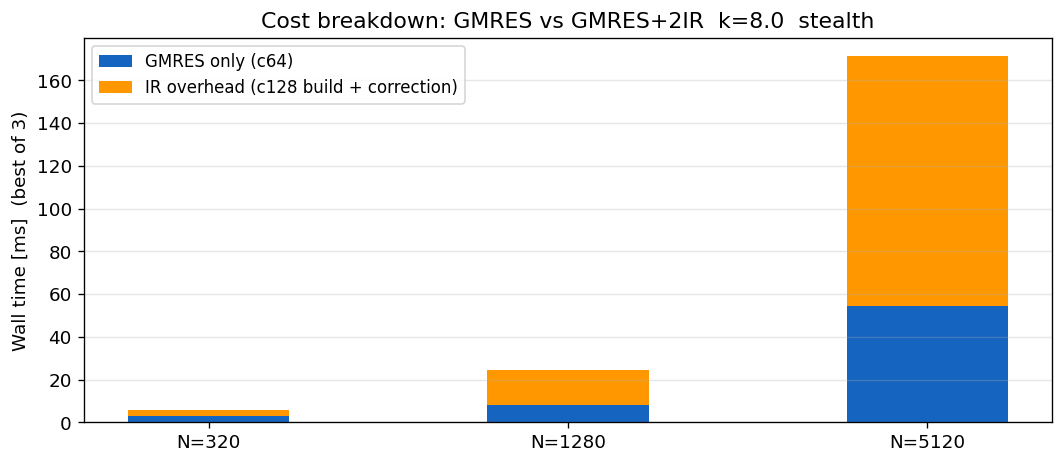

In [9]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(9, 4))
N_labels = [str(r[0]) for r in timing_rows]
t_base   = [r[1] for r in timing_rows]
t_extra  = [r[3] - r[1] for r in timing_rows]
x        = np.arange(len(N_labels))
w        = 0.45

ax.bar(x, t_base,  w, label='GMRES only (c64)', color='#1565C0')
ax.bar(x, t_extra, w, bottom=t_base, label='IR overhead (c128 build + correction)',
       color='#FF9800')

ax.set_xticks(x); ax.set_xticklabels([f'N={l}' for l in N_labels])
ax.set_ylabel('Wall time [ms]  (best of 3)')
ax.set_title(f'Cost breakdown: GMRES vs GMRES+2IR  k={k_demo}  stealth')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_stage6_3d_cost.png', dpi=120, bbox_inches='tight')
plt.show()


## § 5 — Mie Error Budget (sphere, multiple k and N)

In [10]:
from mie_sphere_3d import mie_soft_sphere_rcs

print("Error budget: sphere  k=3  nose-on incidence")
print(f"  {'N':>5}  {'BEM max err [dB]':>17}  {'GMRES res':>11}  {'IR-2 res':>10}")
print("  " + "-" * 50)

theta_obs = np.linspace(0, np.pi, 91)
obs_xz    = np.stack([np.sin(theta_obs), np.zeros_like(theta_obs),
                      np.cos(theta_obs)], axis=1)
rcs_mie   = mie_soft_sphere_rcs(3.0, 1.0, theta_obs)
ref_db    = 10 * np.log10(np.maximum(rcs_mie, 1e-20))

for N_t in [80, 320, 1280]:
    n_s, _, a_s = TARGETS[0]['geom_fn'](N_t, 3.0)
    b_s = make_rhs_3d(n_s, 3.0, np.array([0.,0.,1.]))
    x0, _, r0 = asm.solve_ir(n_s, a_s, 3.0, b_s, tol=1e-6, maxiter_ir=0)
    x2, _, r2 = asm.solve_ir(n_s, a_s, 3.0, b_s, tol=1e-10, maxiter_ir=2)
    rcs0_db = 10*np.log10(np.maximum(
        bistatic_sphere_sweep(n_s, a_s, x0, 3.0,
                              theta_obs, np.zeros(1)).ravel(), 1e-20))
    err_bem = np.abs(rcs0_db - ref_db).max()
    print(f"  {len(n_s):>5}  {err_bem:>17.4f}  {r0:>11.2e}  {r2:>10.2e}")


Error budget: sphere  k=3  nose-on incidence
      N   BEM max err [dB]    GMRES res    IR-2 res
  --------------------------------------------------
     80             0.7433     5.00e-07    4.47e-14
    320             0.1622     5.83e-07    1.10e-13
   1280             0.0273     5.74e-07    4.10e-12


In [11]:
# Summary table
print()
print("=" * 60)
print("STAGE 6 SUMMARY — 3D Mixed-Precision IR")
print("=" * 60)
print()
print("The 3D precision ladder (stealth body, k=8):")
print()
print(f"  Solver              Residual       RCS effect")
print(f"  {'-'*50}")
for maxir, label in [(0, 'GMRES c64'), (1, 'GMRES+1IR'), (2, 'GMRES+2IR')]:
    x_t, _, rr = asm.solve_ir(nodes, areas, k_demo,
                               make_rhs_3d(nodes, k_demo, inc),
                               tol=1e-6, maxiter_ir=maxir)
    rcs_t = bistatic_sphere_sweep(nodes, areas, x_t, k_demo, OBS_THETA, OBS_PHI)
    rcs_t_db = 10*np.log10(np.maximum(rcs_t, 1e-20))
    diff_t = np.abs(rcs_t_db - rcs_ir_db).max()
    print(f"  {label:20s}  {rr:.2e}  max RCS diff vs IR-2: {diff_t:.4f} dB")

print()
print("Condition numbers (N=80) near kR=pi resonance:")
for name in ['Sphere','Cube','Stealth']:
    row = cond_table[name]
    k_max_idx = np.argmax(row)
    print(f"  {name:10s}: max kappa={row[k_max_idx]:.0f} at k={WAVENUMBERS[k_max_idx]:.0f}")
print()
print("IR overhead at N=5120: see cost breakdown chart.")
print("Recommended: use IR when publishing null depths or lobe positions.")



STAGE 6 SUMMARY — 3D Mixed-Precision IR

The 3D precision ladder (stealth body, k=8):

  Solver              Residual       RCS effect
  --------------------------------------------------
  GMRES c64             1.29e-04  max RCS diff vs IR-2: 0.0170 dB
  GMRES+1IR             1.29e-04  max RCS diff vs IR-2: 0.0001 dB
  GMRES+2IR             1.44e-06  max RCS diff vs IR-2: 0.0000 dB

Condition numbers (N=80) near kR=pi resonance:
  Sphere    : max kappa=31 at k=16
  Cube      : max kappa=241 at k=16
  Stealth   : max kappa=5136 at k=5

IR overhead at N=5120: see cost breakdown chart.
Recommended: use IR when publishing null depths or lobe positions.
